# 01 — Exploratory Data Analysis (EDA)
## Atlantic Haven Hotels — Prédiction d'annulation de réservation

**Rôle : ANDRIANTSOA Velotiana Todisoa Angelo — Data Analyst (EDA)**

Objectifs de ce notebook :
- Analyser la cible `reservation_annulee` et son déséquilibre de classes
- Étudier les valeurs manquantes, les distributions, les valeurs atypiques
- Étudier la dimension temporelle (train vs test) qui **doit** guider le protocole de validation (Q4)
- Identifier les scénarios / profils fréquents d'annulation (Q5)
- Produire les figures clés pour le README et la vidéo (Membre 7)


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.dpi'] = 100

print("Setup OK — graine aléatoire fixée à", RANDOM_SEED)

Setup OK — graine aléatoire fixée à 42


## 1. Chargement des données

In [7]:
RAW_DIR = "../data/raw"

train = pd.read_csv(f"{RAW_DIR}/reservations_train.csv", parse_dates=['date_reservation', 'date_arrivee'])
test  = pd.read_csv(f"{RAW_DIR}/reservations_test.csv",  parse_dates=['date_reservation', 'date_arrivee'])
data_dict = pd.read_csv(f"{RAW_DIR}/data_dictionary.csv")

print("Train :", train.shape)
print("Test  :", test.shape)

Train : (8000, 34)
Test  : (2000, 33)


In [8]:
data_dict

,variable,type,description,fichier_test
0,reservation_id,identifiant,Identifiant unique de la réservation,oui
1,date_reservation,date,Date de création de la réservation,oui
2,date_arrivee,date,Date d’arrivée prévue,oui
3,region_hotel,catégorielle,Région administrative italienne de l’hôtel,oui
4,ville,catégorielle,Ville principale associée à l’établissement,oui
5,type_destination,catégorielle,Profil touristique dominant de la destination,oui
6,hotel_id,catégorielle,Identifiant synthétique de l’hôtel,oui
7,categorie_hotel,entier,"Catégorie de l’hôtel, en étoiles",oui
8,segment_client,catégorielle,Motif ou composition principale du séjour,oui
9,marche_origine,catégorielle,"Grande zone de marché, non assimilable à une n...",oui


In [9]:
train.head()

,reservation_id,date_reservation,date_arrivee,region_hotel,ville,type_destination,hotel_id,categorie_hotel,segment_client,marche_origine,canal_reservation,moyen_transport,delai_reservation_jours,nuits,adultes,enfants,chambres,formule_repas,tarif_remboursable,type_acompte,prix_moyen_nuit_eur,remise_pct,montant_total_eur,client_type,reservations_passees,annulations_passees,demandes_speciales,modifications_reservation,jours_liste_attente,evenement_majeur,haute_saison_regionale,arrivee_weekend,agent_id,reservation_annulee
0,R000808,2023-01-01,2023-03-13,Campania,Napoli,urbaine_cotiere,CAM-4-2,4,loisirs_couple,Europe_Ouest,plateforme_en_ligne,avion_direct,71,4,2,0.0,1,aucune,non,total,165.72,3,642.99,nouveau,0,0,1.0,0,0,0,0,0,AG036,0
1,R001808,2023-01-01,2023-01-07,Lazio,Roma,urbaine_culturelle,LAZ-4-3,4,affaires,Ameriques,plateforme_en_ligne,train,6,3,2,1.0,1,petit_dejeuner,oui,partiel,187.00,0,561.00,fidele,9,1,2.0,1,0,0,0,1,AG005,1
2,R002130,2023-01-01,2023-03-26,Lombardia,Milano,affaires_lacs,LOM-4-2,4,loisirs_couple,Autres,agence,avion_direct,84,3,2,0.0,1,aucune,oui,aucun,180.61,1,536.41,nouveau,0,0,2.0,2,0,0,0,0,AG043,1
3,R003635,2023-01-01,2023-01-09,Liguria,Genova,littorale,LIG-4-1,4,famille,Ameriques,plateforme_en_ligne,voiture,8,3,2,1.0,1,petit_dejeuner,oui,aucun,202.10,7,563.86,nouveau,0,0,0.0,0,0,1,0,0,AG031,0
4,R004683,2023-01-01,2023-01-11,Sardegna,Cagliari,insulaire_balneaire,SAR-3-2,3,loisirs_couple,Italie,site_hotel,ferry,10,4,2,0.0,1,petit_dejeuner,non,total,138.89,4,533.34,nouveau,0,0,2.0,1,0,0,0,0,NaN,0


In [10]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   reservation_id             8000 non-null   object        
 1   date_reservation           8000 non-null   datetime64[ns]
 2   date_arrivee               8000 non-null   datetime64[ns]
 3   region_hotel               8000 non-null   object        
 4   ville                      8000 non-null   object        
 5   type_destination           8000 non-null   object        
 6   hotel_id                   8000 non-null   object        
 7   categorie_hotel            8000 non-null   int64         
 8   segment_client             8000 non-null   object        
 9   marche_origine             7809 non-null   object        
 10  canal_reservation          8000 non-null   object        
 11  moyen_transport            8000 non-null   object        
 12  delai_

## 2. Qualité des données : doublons, cohérence des dates

On vérifie l'absence de doublons d'identifiants, le chevauchement train/test, et la cohérence
`date_arrivee >= date_reservation`.

In [11]:
print("Doublons reservation_id (train) :", train['reservation_id'].duplicated().sum())
print("Doublons reservation_id (test)  :", test['reservation_id'].duplicated().sum())
print("Chevauchement d'identifiants train/test :", len(set(train['reservation_id']) & set(test['reservation_id'])))

incoherent = (train['date_arrivee'] < train['date_reservation']).sum()
print("Lignes avec date_arrivee < date_reservation :", incoherent)

# Cohérence delai_reservation_jours vs (date_arrivee - date_reservation)
delai_recalcule = (train['date_arrivee'] - train['date_reservation']).dt.days
ecart = (delai_recalcule - train['delai_reservation_jours']).abs().max()
print("Écart max entre delai_reservation_jours et le delai recalculé à partir des dates :", ecart)

Doublons reservation_id (train) : 0
Doublons reservation_id (test)  : 0
Chevauchement d'identifiants train/test : 0
Lignes avec date_arrivee < date_reservation : 0
Écart max entre delai_reservation_jours et le delai recalculé à partir des dates : 0


**Constat :** aucun doublon, aucun chevauchement d'ID entre train et test, aucune incohérence de date,
et `delai_reservation_jours` est parfaitement cohérent avec les deux dates fournies. Les données sont propres
sur ce plan.

## 3. Dimension temporelle — point CRITIQUE pour la validation (Q4)

Le sujet insiste : *"les fichiers sont ordonnés dans le temps et le jeu de test représente des réservations
plus récentes que celles de l'entraînement"*. On vérifie et on quantifie cela précisément.

In [12]:
print("=== date_reservation ===")
print("Train :", train['date_reservation'].min().date(), "->", train['date_reservation'].max().date())
print("Test  :", test['date_reservation'].min().date(),  "->", test['date_reservation'].max().date())
print()
print("=== date_arrivee ===")
print("Train :", train['date_arrivee'].min().date(), "->", train['date_arrivee'].max().date())
print("Test  :", test['date_arrivee'].min().date(),  "->", test['date_arrivee'].max().date())

=== date_reservation ===
Train : 2023-01-01 -> 2025-05-24
Test  : 2025-05-24 -> 2025-12-31

=== date_arrivee ===
Train : 2023-01-04 -> 2026-06-02
Test  : 2025-05-29 -> 2027-03-11


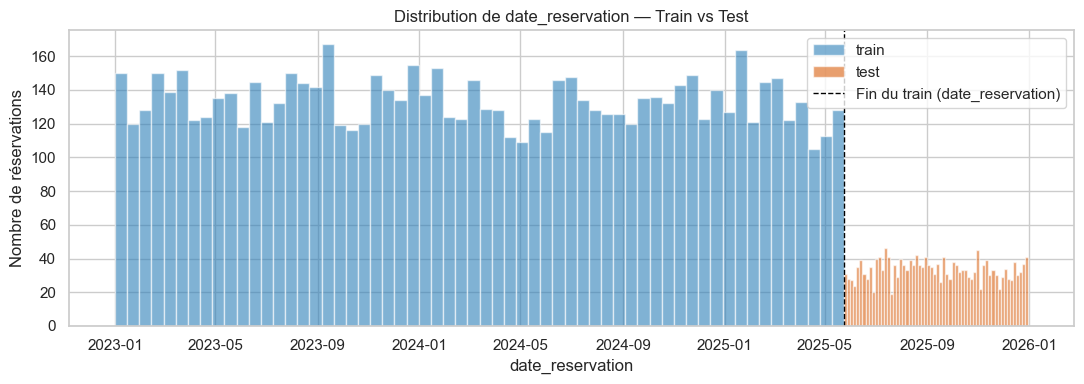

In [13]:
train['flag'] = 'train'
test_flag = test.copy()
test_flag['flag'] = 'test'
combined = pd.concat([train[['date_reservation','flag']], test_flag[['date_reservation','flag']]])

fig, ax = plt.subplots(figsize=(11,4))
for flag, color in [('train', '#2c7fb8'), ('test', '#d95f0e')]:
    subset = combined[combined['flag']==flag]
    ax.hist(subset['date_reservation'], bins=60, alpha=0.6, label=flag, color=color)
ax.axvline(train['date_reservation'].max(), color='black', linestyle='--', linewidth=1,
           label='Fin du train (date_reservation)')
ax.set_title("Distribution de date_reservation — Train vs Test")
ax.set_xlabel("date_reservation")
ax.set_ylabel("Nombre de réservations")
ax.legend()
plt.tight_layout()
plt.savefig('../report/figures/01_train_test_dates.png', dpi=120)
plt.show()

train = train.drop(columns=['flag'])

**Constat majeur (→ Q4) :** le train couvre `date_reservation` de janvier 2023 à fin mai 2025 ; le test
prend le relais exactement là où le train s'arrête (fin mai 2025) et va jusqu'à fin décembre 2025. Il n'y a
**aucun chevauchement temporel**. Un split aléatoire (K-fold classique) mélangerait des réservations passées et
futures dans le même pli, ce qui permettrait au modèle de "voir" indirectement des tendances proches de la
période de test lors de l'entraînement — **fuite temporelle** et estimation optimiste. Le protocole retenu doit
découper le train de façon chronologique (ex. les 15–20% dernières semaines de `date_reservation` comme
validation), afin de simuler la même situation que celle du test : prédire des réservations plus récentes que
celles vues à l'entraînement.

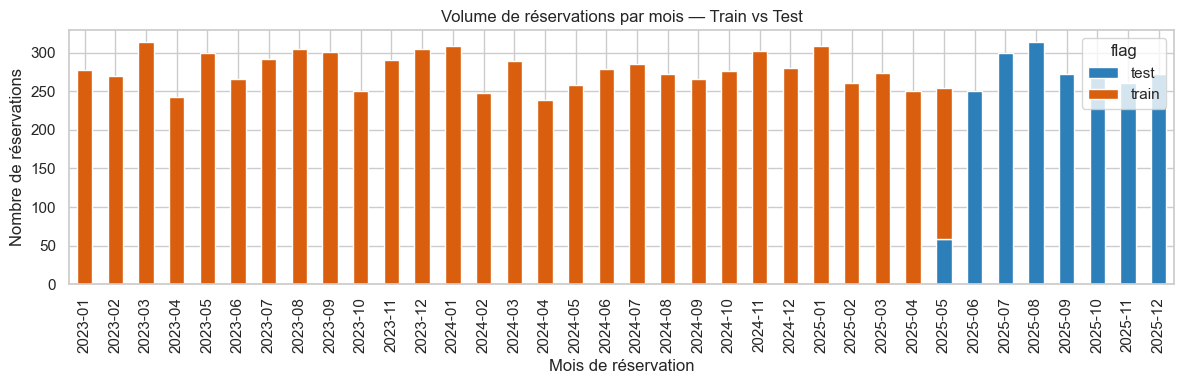

In [14]:
# Zoom : nombre de réservations par mois de date_reservation (train + test)
combined2 = pd.concat([train.assign(flag='train'), test.assign(flag='test')], ignore_index=True)
combined2['mois_reservation'] = combined2['date_reservation'].dt.to_period('M').astype(str)

monthly_counts = combined2.groupby(['mois_reservation','flag']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12,4))
monthly_counts.plot(kind='bar', stacked=True, ax=ax, color=['#2c7fb8','#d95f0e'])
ax.set_title("Volume de réservations par mois — Train vs Test")
ax.set_xlabel("Mois de réservation")
ax.set_ylabel("Nombre de réservations")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('../report/figures/02_volume_mensuel.png', dpi=120)
plt.show()

## 4. Analyse de la cible `reservation_annulee`

reservation_annulee
0    5933
1    2067
Name: count, dtype: int64

reservation_annulee
0    74.16 %
1    25.84 %
Name: proportion, dtype: object


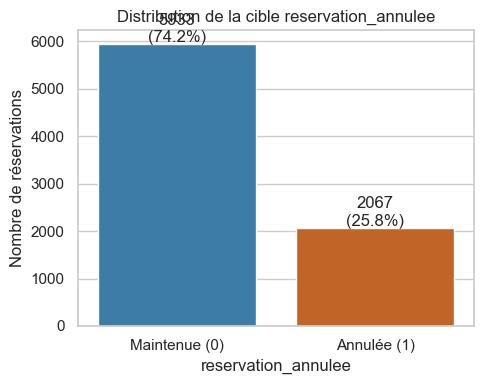

In [15]:
target_counts = train['reservation_annulee'].value_counts().sort_index()
target_pct = train['reservation_annulee'].value_counts(normalize=True).sort_index() * 100

print(target_counts)
print()
print(target_pct.round(2).astype(str) + ' %')

fig, ax = plt.subplots(figsize=(5,4))
sns.barplot(x=target_counts.index.map({0:'Maintenue (0)',1:'Annulée (1)'}), y=target_counts.values,
            ax=ax, palette=['#2c7fb8','#d95f0e'])
ax.set_title("Distribution de la cible reservation_annulee")
ax.set_ylabel("Nombre de réservations")
for i, v in enumerate(target_counts.values):
    ax.text(i, v+50, f"{v}\n({target_pct.values[i]:.1f}%)", ha='center')
plt.tight_layout()
plt.savefig('../report/figures/03_target_distribution.png', dpi=120)
plt.show()

**Constat :** la classe «annulée » représente **25,8 %** des réservations du train — déséquilibre modéré
mais réel (ratio ~2.9:1). Cela justifie l'usage du F1-score sur la classe minoritaire plutôt que l'accuracy
(→ Q1), et impose d'être vigilant sur le seuil de décision, le poids des classes, et le choix des métriques
de validation.

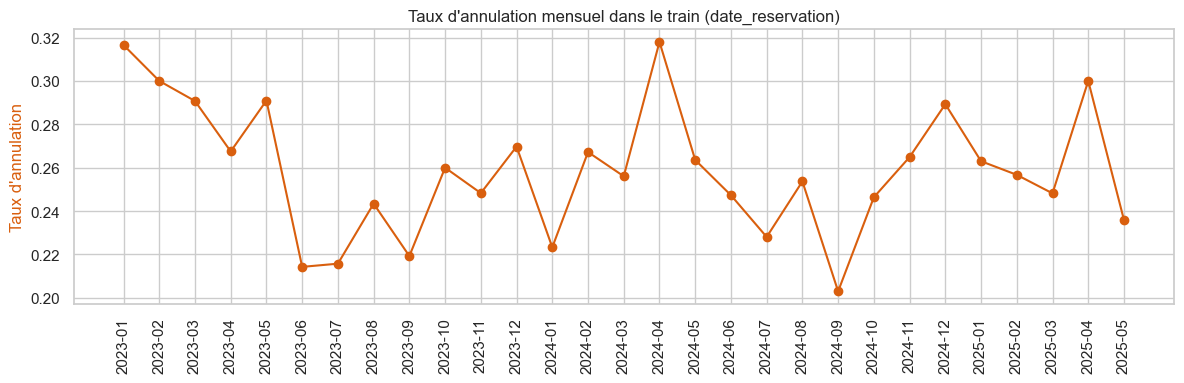

                   mean  count
mois_reservation              
2023-01           0.317    278
2023-02           0.300    270
2023-03           0.291    313
2023-04           0.267    243
2023-05           0.291    299
2023-06           0.214    266
2023-07           0.216    292
2023-08           0.243    304
2023-09           0.219    301
2023-10           0.260    250
2023-11           0.248    290
2023-12           0.270    304
2024-01           0.223    309
2024-02           0.267    247
2024-03           0.256    289
2024-04           0.318    239
2024-05           0.264    258
2024-06           0.247    279
2024-07           0.228    285
2024-08           0.254    272
2024-09           0.203    266
2024-10           0.246    276
2024-11           0.265    302
2024-12           0.289    280
2025-01           0.263    308
2025-02           0.257    261
2025-03           0.248    274
2025-04           0.300    250
2025-05           0.236    195


In [16]:
# Taux d'annulation dans le temps : la cible est-elle stable ou dérive-t-elle ?
train['mois_reservation'] = train['date_reservation'].dt.to_period('M').astype(str)
monthly_rate = train.groupby('mois_reservation')['reservation_annulee'].agg(['mean','count'])

fig, ax1 = plt.subplots(figsize=(12,4))
ax1.plot(monthly_rate.index, monthly_rate['mean'], marker='o', color='#d95f0e')
ax1.set_ylabel("Taux d'annulation", color='#d95f0e')
ax1.set_title("Taux d'annulation mensuel dans le train (date_reservation)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('../report/figures/04_taux_annulation_mensuel.png', dpi=120)
plt.show()

print(monthly_rate.round(3))

**Constat :** le taux d'annulation mensuel oscille entre ~20% et ~32% sans tendance de dérive forte ni
saisonnalité évidente sur la période du train — la cible semble raisonnablement stable dans le temps, ce qui est
plutôt rassurant pour la généralisation au test, même s'il faut le confirmer avec la validation temporelle.

## 5. Valeurs manquantes

In [17]:
def missing_report(df, name):
    miss = df.isna().sum()
    miss = miss[miss > 0].sort_values(ascending=False)
    pct = (miss / len(df) * 100).round(2)
    report = pd.DataFrame({'n_manquant': miss, 'pct_manquant': pct})
    print(f"--- {name} ---")
    print(report)
    print()
    return report

miss_train = missing_report(train, "TRAIN")
miss_test = missing_report(test, "TEST")

--- TRAIN ---
                     n_manquant  pct_manquant
agent_id                   3354         41.92
enfants                     355          4.44
prix_moyen_nuit_eur         193          2.41
marche_origine              191          2.39
demandes_speciales          157          1.96

--- TEST ---
                     n_manquant  pct_manquant
agent_id                    831         41.55
enfants                      88          4.40
marche_origine               52          2.60
prix_moyen_nuit_eur          34          1.70
demandes_speciales           29          1.45



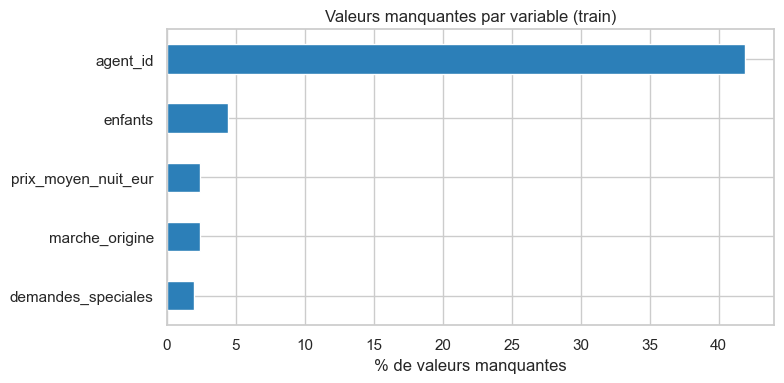

In [18]:
fig, ax = plt.subplots(figsize=(8,4))
miss_train['pct_manquant'].sort_values().plot(kind='barh', ax=ax, color='#2c7fb8')
ax.set_xlabel("% de valeurs manquantes")
ax.set_title("Valeurs manquantes par variable (train)")
plt.tight_layout()
plt.savefig('../report/figures/05_valeurs_manquantes.png', dpi=120)
plt.show()

In [19]:
# agent_id : la valeur manquante est-elle structurelle (canal direct) ?
pd.crosstab(train['canal_reservation'], train['agent_id'].isna().map({True:'agent manquant', False:'agent renseigné'}))

agent_id,agent manquant,agent renseigné
canal_reservation,,
agence,0,1325
entreprise,622,0
plateforme_en_ligne,0,3321
site_hotel,2013,0
telephone,719,0


**Constat sur `agent_id` (42% de manquants) :** ce n'est PAS aléatoire — l'agent est systématiquement
absent pour les canaux directs (`site_hotel`, `telephone`, `entreprise`) et systématiquement présent pour les
canaux intermédiés (`agence`, `plateforme_en_ligne`). C'est une absence **structurelle et informative**, pas
une donnée manquante à imputer : on peut la recoder en catégorie explicite `"aucun_agent"` / ou en dériver un
indicateur binaire `a_un_agent`, plutôt que d'imputer une valeur arbitraire (→ Q6).

In [20]:
# Les autres variables manquantes (marche_origine, enfants, prix_moyen_nuit_eur, demandes_speciales)
# sont-elles informatives sur la cible (MNAR) ou plutôt aléatoires (MCAR/MAR) ?
for col in ['marche_origine', 'enfants', 'prix_moyen_nuit_eur', 'demandes_speciales']:
    taux_manquant = train.loc[train[col].isna(), 'reservation_annulee'].mean()
    taux_present  = train.loc[train[col].notna(), 'reservation_annulee'].mean()
    print(f"{col:25s} | taux annulation si manquant = {taux_manquant:.3f} | si présent = {taux_present:.3f}")

marche_origine            | taux annulation si manquant = 0.209 | si présent = 0.260
enfants                   | taux annulation si manquant = 0.282 | si présent = 0.257
prix_moyen_nuit_eur       | taux annulation si manquant = 0.181 | si présent = 0.260
demandes_speciales        | taux annulation si manquant = 0.280 | si présent = 0.258


**Constat :** les écarts de taux d'annulation entre "valeur manquante" et "valeur présente" restent
faibles pour `enfants` et `demandes_speciales` (proches du hasard), un peu plus marqués pour `marche_origine`
et surtout `prix_moyen_nuit_eur` (18% vs 26%) — à garder en tête, mais rien qui indique un mécanisme
fortement informatif comparable à `agent_id`. Une imputation simple (médiane pour le numérique, catégorie
"inconnu" pour le catégoriel), **apprise uniquement sur le train**, est raisonnable pour ces variables.

## 6. Variables catégorielles — cardinalité et redondance

In [21]:
# Selection robuste des colonnes categorielles (compatible toutes versions de pandas :
# selon la version, les colonnes texte sont typees 'object' ou 'str'/'string')
cat_cols = [c for c in train.columns
            if c != 'reservation_id' and pd.api.types.is_string_dtype(train[c])]

card = train[cat_cols].nunique().sort_values(ascending=False)
print(card)

hotel_id              84
mois_reservation      29
ville                 10
region_hotel          10
type_destination      10
segment_client         5
moyen_transport        5
canal_reservation      5
formule_repas          4
type_acompte           3
client_type            3
tarif_remboursable     2
dtype: int64


In [22]:
# region_hotel / ville / type_destination semblent liées : vérification
print("Nb de villes distinctes par région :")
print((pd.crosstab(train['region_hotel'], train['ville']) > 0).sum(axis=1))
print()
print("Nb de types de destination distincts par région :")
print((pd.crosstab(train['region_hotel'], train['type_destination']) > 0).sum(axis=1))
print()
print("Nb d'hôtels distincts par région :")
print(train.groupby('region_hotel')['hotel_id'].nunique())

Nb de villes distinctes par région :
region_hotel
Campania               1
Lazio                  1
Liguria                1
Lombardia              1
Puglia                 1
Sardegna               1
Sicilia                1
Toscana                1
Trentino-Alto_Adige    1
Veneto                 1
dtype: int64

Nb de types de destination distincts par région :
region_hotel
Campania               1
Lazio                  1
Liguria                1
Lombardia              1
Puglia                 1
Sardegna               1
Sicilia                1
Toscana                1
Trentino-Alto_Adige    1
Veneto                 1
dtype: int64

Nb d'hôtels distincts par région :
region_hotel
Campania               9
Lazio                  9
Liguria                6
Lombardia              9
Puglia                 6
Sardegna               9
Sicilia                9
Toscana                9
Trentino-Alto_Adige    9
Veneto                 9
Name: hotel_id, dtype: int64


**Constat important (redondance) :** `region_hotel`, `ville` et `type_destination` sont en
**correspondance biunivoque (1 pour 1)** dans ce jeu de données — chaque région ne contient qu'une seule ville
et un seul type de destination. Ce sont donc trois encodages différents de la même information géographique.
Il faudra n'en garder qu'une ou deux pour éviter la redondance/colinéarité (le feature engineer peut par
exemple garder `region_hotel` + dériver un `type_destination` regroupé, et laisser tomber `ville`).
`hotel_id` (84 modalités) est imbriqué dans `region_hotel` (6 à 9 hôtels par région) — cardinalité trop élevée
pour un one-hot direct ; à traiter en feature engineering (fréquence, target encoding prudent, ou abandon).

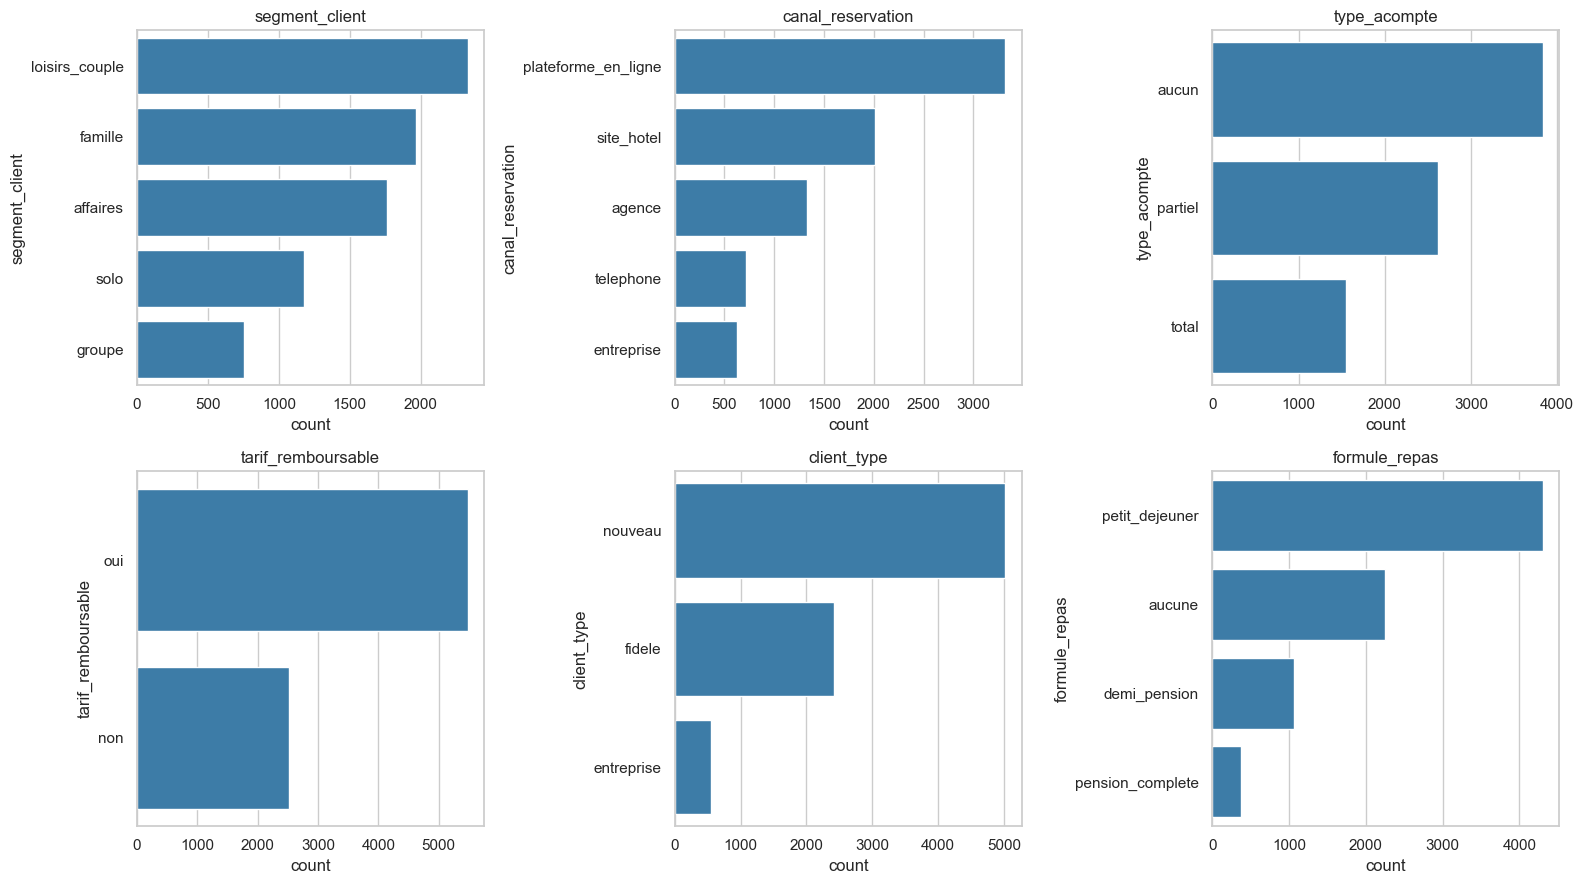

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(16,9))
plot_cols = ['segment_client','canal_reservation','type_acompte','tarif_remboursable','client_type','formule_repas']
for ax, col in zip(axes.flat, plot_cols):
    order = train[col].value_counts().index
    sns.countplot(data=train, y=col, order=order, ax=ax, color='#2c7fb8')
    ax.set_title(col)
plt.tight_layout()
plt.savefig('../report/figures/06_categorielles_distribution.png', dpi=120)
plt.show()

## 7. Variables numériques — distributions et valeurs atypiques

In [24]:
num_cols = ['delai_reservation_jours','nuits','adultes','enfants','chambres',
            'prix_moyen_nuit_eur','remise_pct','montant_total_eur',
            'reservations_passees','annulations_passees','demandes_speciales',
            'modifications_reservation','jours_liste_attente']

train[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
delai_reservation_jours,8000.0,41.379625,49.232410,1.00,16.000,29.00,49.00,584.00
nuits,8000.0,4.203375,2.524492,1.00,2.000,4.00,6.00,30.00
adultes,8000.0,2.086125,0.914364,1.00,2.000,2.00,2.00,6.00
enfants,7645.0,0.529235,0.943367,0.00,0.000,0.00,1.00,3.00
chambres,8000.0,1.266875,0.664423,1.00,1.000,1.00,1.00,4.00
prix_moyen_nuit_eur,7807.0,201.473548,62.550478,75.25,158.945,191.58,233.21,848.42
remise_pct,8000.0,4.999625,3.649629,0.00,2.000,5.00,7.00,18.00
montant_total_eur,8000.0,1009.584740,879.585635,85.44,475.615,786.95,1252.42,13509.19
reservations_passees,8000.0,2.416875,3.785879,0.00,0.000,0.00,4.00,12.00
annulations_passees,8000.0,0.341250,0.602573,0.00,0.000,0.00,1.00,3.00


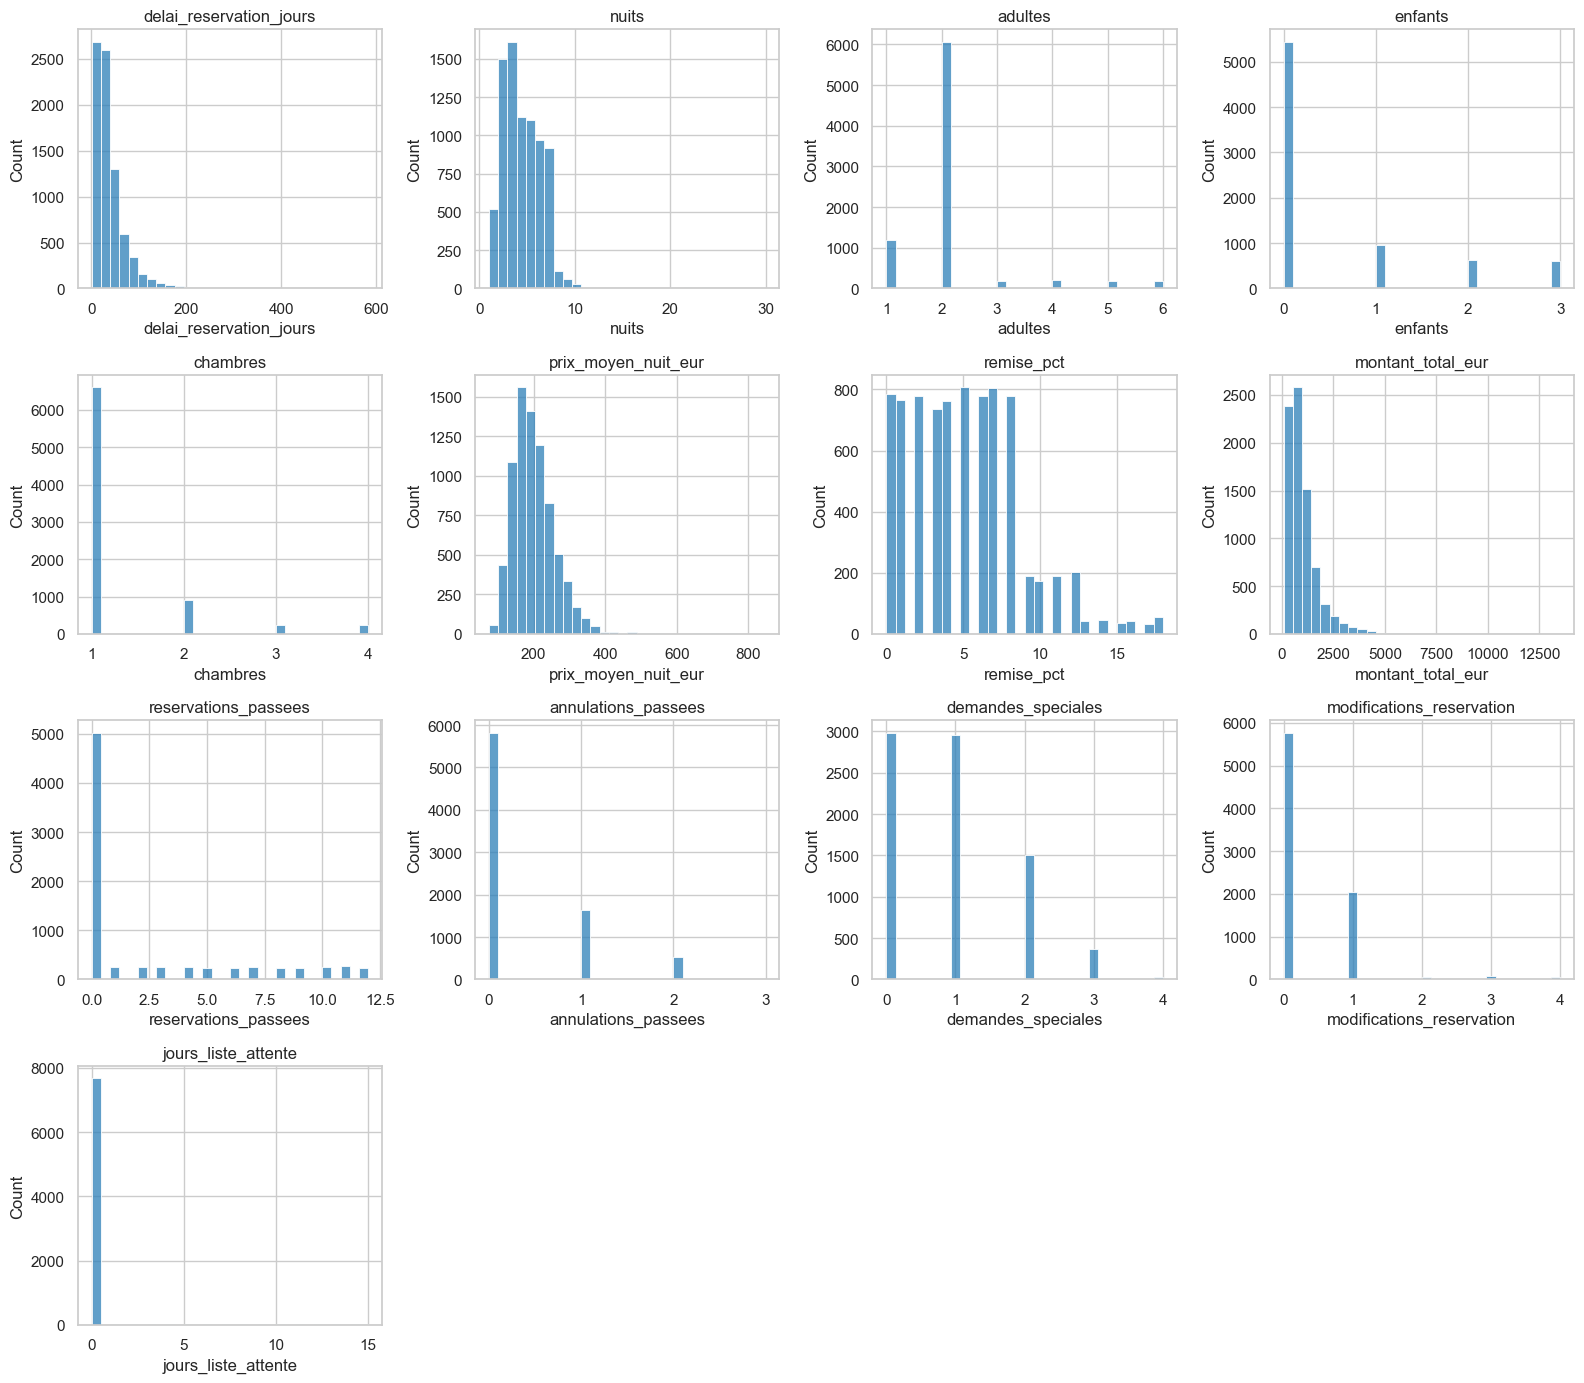

In [25]:
fig, axes = plt.subplots(4, 4, figsize=(16,14))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(train[col].dropna(), bins=30, ax=ax, color='#2c7fb8')
    ax.set_title(col)
for ax in axes.flat[len(num_cols):]:
    ax.axis('off')
plt.tight_layout()
plt.savefig('../report/figures/07_numeriques_distribution.png', dpi=120)
plt.show()

In [26]:
# Valeurs atypiques : bornes à 1% / 99%
outlier_report = []
for col in ['delai_reservation_jours','nuits','prix_moyen_nuit_eur','montant_total_eur','remise_pct']:
    q01, q99 = train[col].quantile([0.01, 0.99])
    outlier_report.append({
        'variable': col, 'min': train[col].min(), 'max': train[col].max(),
        'q01': round(q01,1), 'q99': round(q99,1),
        'n_au_dessus_q99': (train[col] > q99).sum()
    })
pd.DataFrame(outlier_report)

,variable,min,max,q01,q99,n_au_dessus_q99
0,delai_reservation_jours,1.00,584.00,5.0,278.0,80
1,nuits,1.00,30.00,1.0,10.0,57
2,prix_moyen_nuit_eur,75.25,848.42,104.8,380.7,79
3,montant_total_eur,85.44,13509.19,139.8,4261.7,80
4,remise_pct,0.00,18.00,0.0,17.0,55


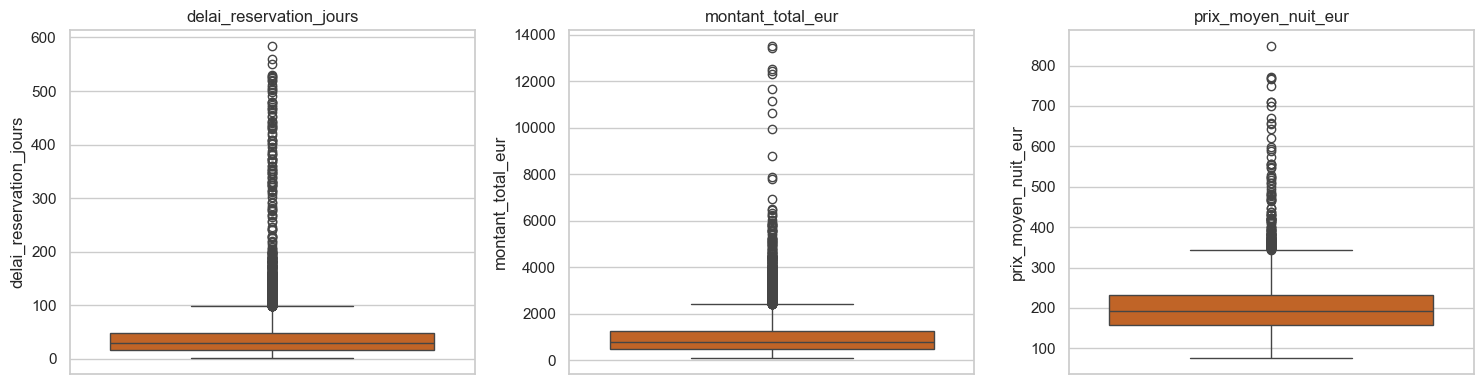

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.boxplot(y=train['delai_reservation_jours'], ax=axes[0], color='#d95f0e'); axes[0].set_title('delai_reservation_jours')
sns.boxplot(y=train['montant_total_eur'], ax=axes[1], color='#d95f0e'); axes[1].set_title('montant_total_eur')
sns.boxplot(y=train['prix_moyen_nuit_eur'], ax=axes[2], color='#d95f0e'); axes[2].set_title('prix_moyen_nuit_eur')
plt.tight_layout()
plt.savefig('../report/figures/08_boxplots_outliers.png', dpi=120)
plt.show()

**Constat sur les valeurs atypiques :**
- `delai_reservation_jours` va jusqu'à **584 jours** (>19 mois à l'avance) : réservations très en avance,
  rares mais réelles — voir plus bas, elles sont fortement associées à l'annulation, donc **à conserver**, pas
  à écrêter aveuglément.
- `montant_total_eur` va jusqu'à **13 509 €** pour une moyenne à ~1 010 € : séjours longs / grands groupes,
  plausible au vu de `nuits` (jusqu'à 30) et `chambres` (jusqu'à 4). À vérifier au cas par cas mais pas
  d'aberration évidente (pas de valeurs négatives ou nulles).
- Aucune valeur négative ou physiquement impossible détectée sur les variables numériques.
- Décision proposée : **ne pas supprimer** ces observations (le F1-score sur la classe minoritaire ne peut pas
  se permettre de perdre des lignes), mais envisager une transformation log pour `montant_total_eur` en
  modélisation linéaire, et un clipping doux uniquement si la régression logistique baseline s'avère instable.

## 8. Relation entre variables et cible — analyse bivariée

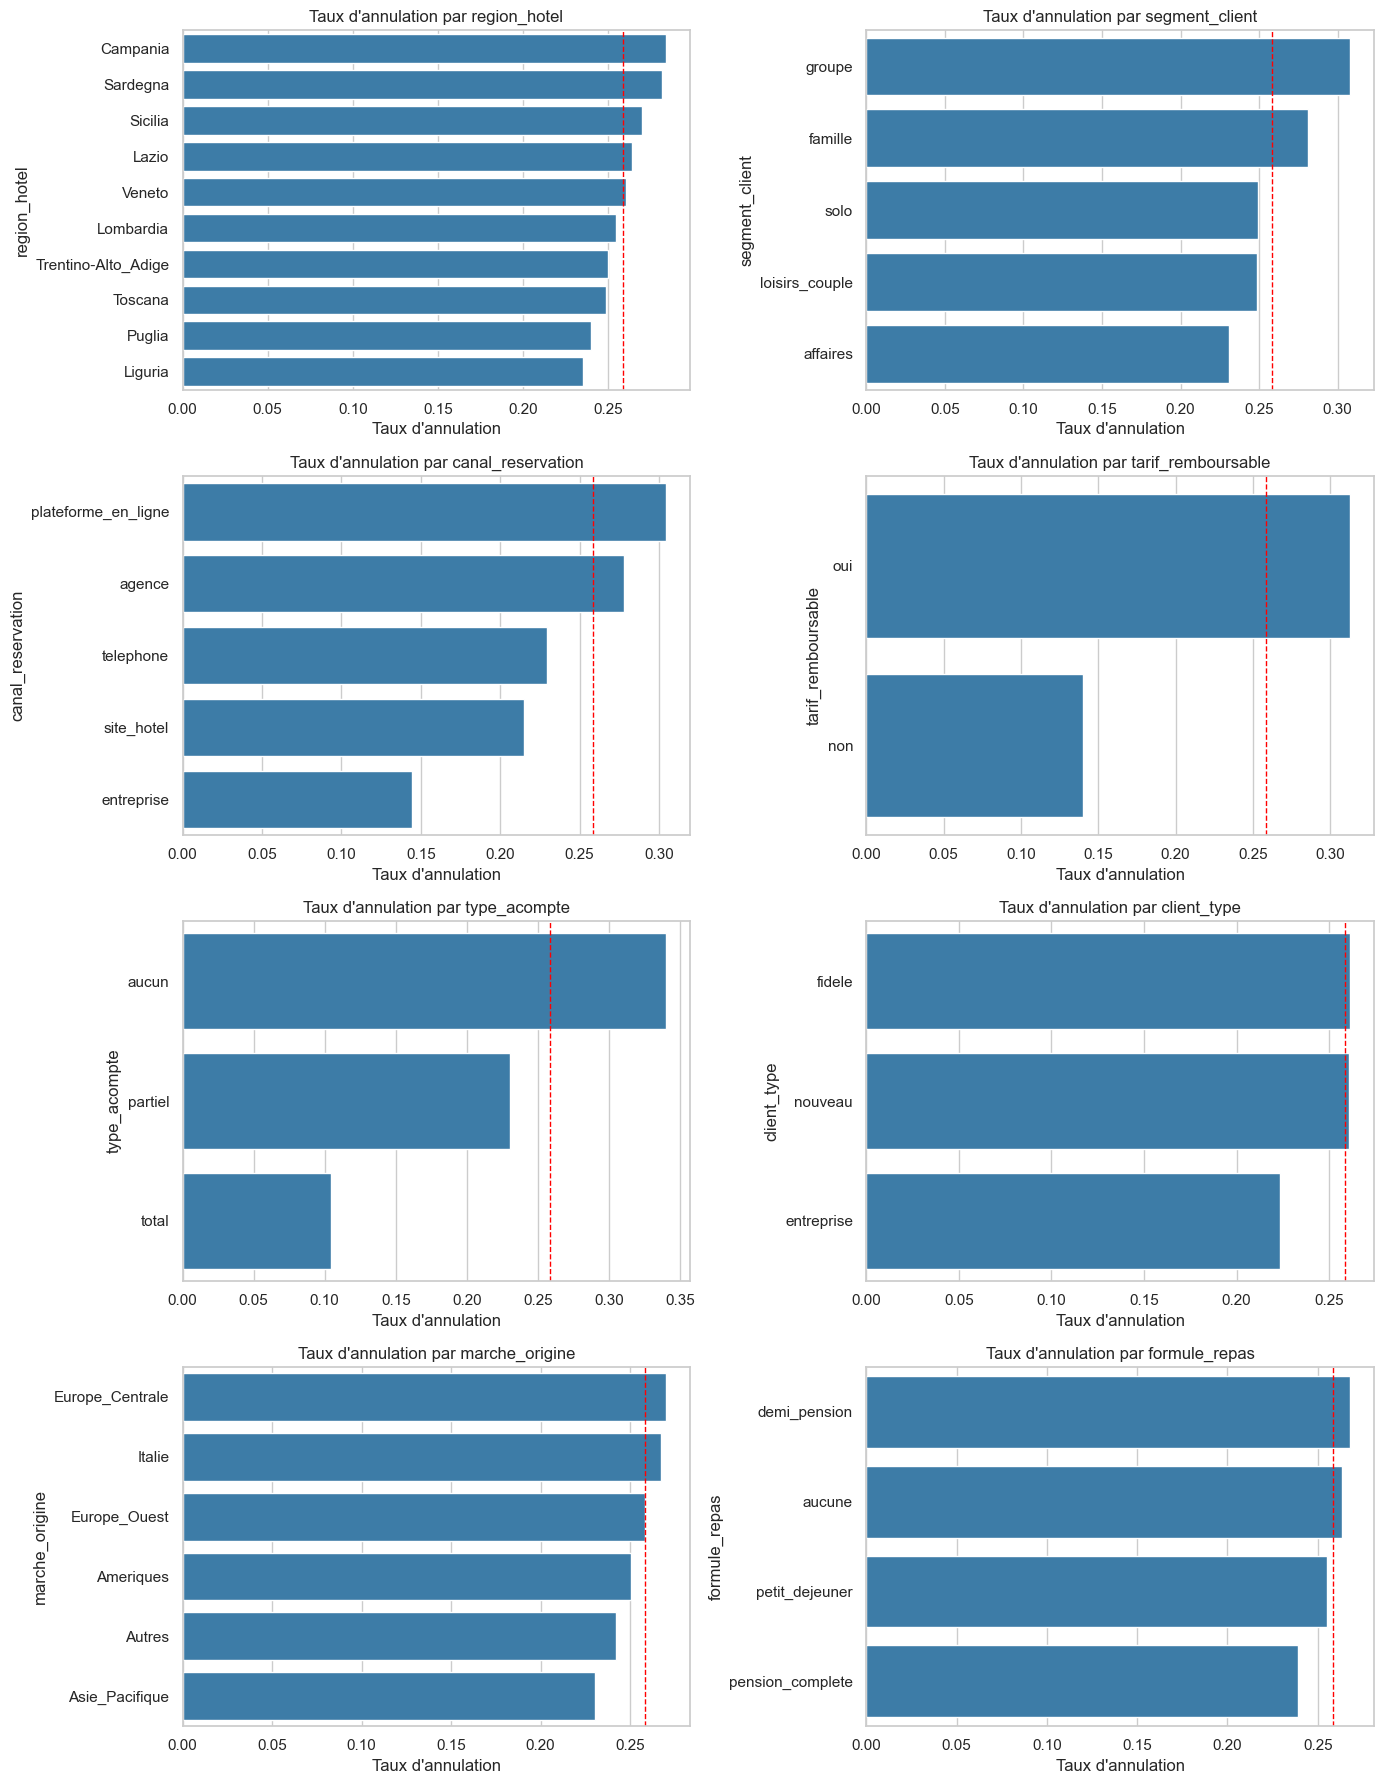

In [28]:
cat_bivar = ['region_hotel','segment_client','canal_reservation','tarif_remboursable',
             'type_acompte','client_type','marche_origine','formule_repas']

fig, axes = plt.subplots(4, 2, figsize=(14,18))
for ax, col in zip(axes.flat, cat_bivar):
    rates = train.groupby(col)['reservation_annulee'].mean().sort_values(ascending=False)
    sns.barplot(x=rates.values, y=rates.index, ax=ax, color='#2c7fb8')
    ax.axvline(train['reservation_annulee'].mean(), color='red', linestyle='--', linewidth=1)
    ax.set_title(f"Taux d'annulation par {col}")
    ax.set_xlabel("Taux d'annulation")
plt.tight_layout()
plt.savefig('../report/figures/09_taux_par_categorie.png', dpi=120)
plt.show()

**Constats (ligne rouge = taux moyen global 25,8%) :**
- `type_acompte` : très discriminant — **aucun acompte → 34,0%** d'annulation vs **acompte total → 10,4%**.
- `tarif_remboursable` : **oui → 31,3%** vs **non → 14,0%** — cohérent, un tarif non remboursable dissuade
  l'annulation.
- `canal_reservation` : **plateforme_en_ligne → 30,4%** (le plus haut) vs **entreprise → 14,5%** (le plus bas).
- `segment_client` : les **groupes (30,8%)** annulent plus que les voyages **affaires (23,1%)**.
- `region_hotel` / `marche_origine` : écarts plus modestes (24–28%), pas de région "anormale" — les écarts
  reflètent des contextes touristiques/commerciaux, pas des caractéristiques de population (rappel du sujet).

In [29]:
# Combinaisons de variables — scénarios de risque (pour Q5)
combo_canal_acompte = train.groupby(['canal_reservation','type_acompte'])['reservation_annulee'].agg(['mean','count'])
combo_canal_acompte.sort_values('mean', ascending=False).head(6)

,,mean,count
canal_reservation,type_acompte,,
plateforme_en_ligne,aucun,0.379902,1632
agence,aucun,0.371383,622
telephone,aucun,0.348571,350
site_hotel,aucun,0.295728,913
plateforme_en_ligne,partiel,0.287865,1063
agence,partiel,0.239910,446


In [30]:
train['delai_bucket'] = pd.cut(train['delai_reservation_jours'],
                               bins=[0,7,30,90,180,600],
                               labels=['0-7j','8-30j','31-90j','91-180j','180j+'])
delai_rate = train.groupby('delai_bucket', observed=True)['reservation_annulee'].agg(['mean','count'])
delai_rate

,mean,count
delai_bucket,,
0-7j,0.231527,406
8-30j,0.234335,3862
31-90j,0.270521,3131
91-180j,0.313559,472
180j+,0.565891,129


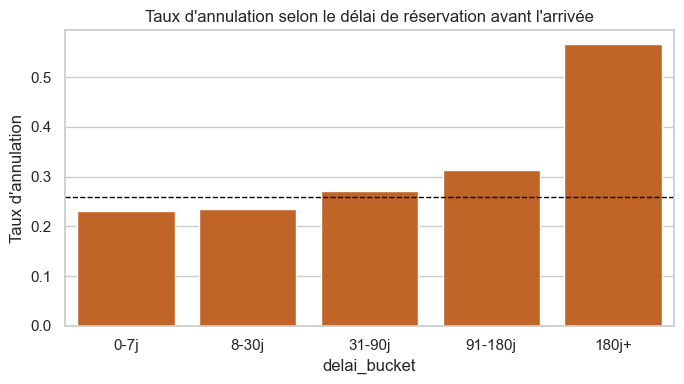

In [31]:
fig, ax = plt.subplots(figsize=(7,4))
sns.barplot(x=delai_rate.index, y=delai_rate['mean'], ax=ax, color='#d95f0e')
ax.axhline(train['reservation_annulee'].mean(), color='black', linestyle='--', linewidth=1)
ax.set_title("Taux d'annulation selon le délai de réservation avant l'arrivée")
ax.set_ylabel("Taux d'annulation")
plt.tight_layout()
plt.savefig('../report/figures/10_taux_par_delai.png', dpi=120)
plt.show()

**Constat fort (→ Q5) :** le délai entre la réservation et l'arrivée est un signal puissant et
**quasi monotone** — le taux d'annulation grimpe de 23% (réservation à moins de 7 jours) à **56,6%** pour les
réservations faites plus de 180 jours à l'avance. C'est le facteur numérique isolé le plus discriminant, et un
excellent candidat de feature engineering (buckets, ou transformation log de `delai_reservation_jours`).

**Scénarios/profils les plus à risque identifiés (pour Q5, à détailler dans le README) :**
1. Réservation **sans acompte**, via **plateforme en ligne** ou **agence** → ~37–38% d'annulation.
2. Réservation faite **plus de 180 jours à l'avance** → 56,6% d'annulation (le plus fort signal observé).
3. Tarif **remboursable** + segment **groupe** → 37,7% d'annulation.
4. À l'inverse, **acompte total** ou **tarif non remboursable** + canal **entreprise** → sous les 15%,
   profils très stables.


In [32]:
# Variables binaires (evenement_majeur, haute_saison_regionale, arrivee_weekend) : effet faible ?
for col in ['evenement_majeur','haute_saison_regionale','arrivee_weekend']:
    print(train.groupby(col)['reservation_annulee'].agg(['mean','count']))
    print()

                      mean  count
evenement_majeur                 
0                 0.257542   7094
1                 0.264901    906

                            mean  count
haute_saison_regionale                 
0                       0.260474   4511
1                       0.255661   3489

                     mean  count
arrivee_weekend                 
0                0.257372   5731
1                0.260908   2269



**Constat :** `evenement_majeur`, `haute_saison_regionale` et `arrivee_weekend` ont individuellement un
effet très faible (écarts de 1 à 4 points) sur le taux d'annulation brut — ils seront probablement plus utiles
en interaction avec d'autres variables (ex. haute saison × délai de réservation) qu'isolément.

In [33]:
# Corrélation des variables numériques avec la cible
corr_target = train[num_cols + ['categorie_hotel','reservation_annulee']].corr(numeric_only=True)['reservation_annulee']
corr_target = corr_target.drop('reservation_annulee').sort_values(key=abs, ascending=False)
corr_target

delai_reservation_jours      0.110531
modifications_reservation    0.059761
remise_pct                  -0.055104
demandes_speciales          -0.054611
chambres                     0.049157
adultes                      0.038409
montant_total_eur            0.037113
enfants                      0.035526
prix_moyen_nuit_eur          0.025695
reservations_passees        -0.018079
jours_liste_attente         -0.013521
annulations_passees         -0.011547
nuits                        0.008781
categorie_hotel              0.008181
Name: reservation_annulee, dtype: float64

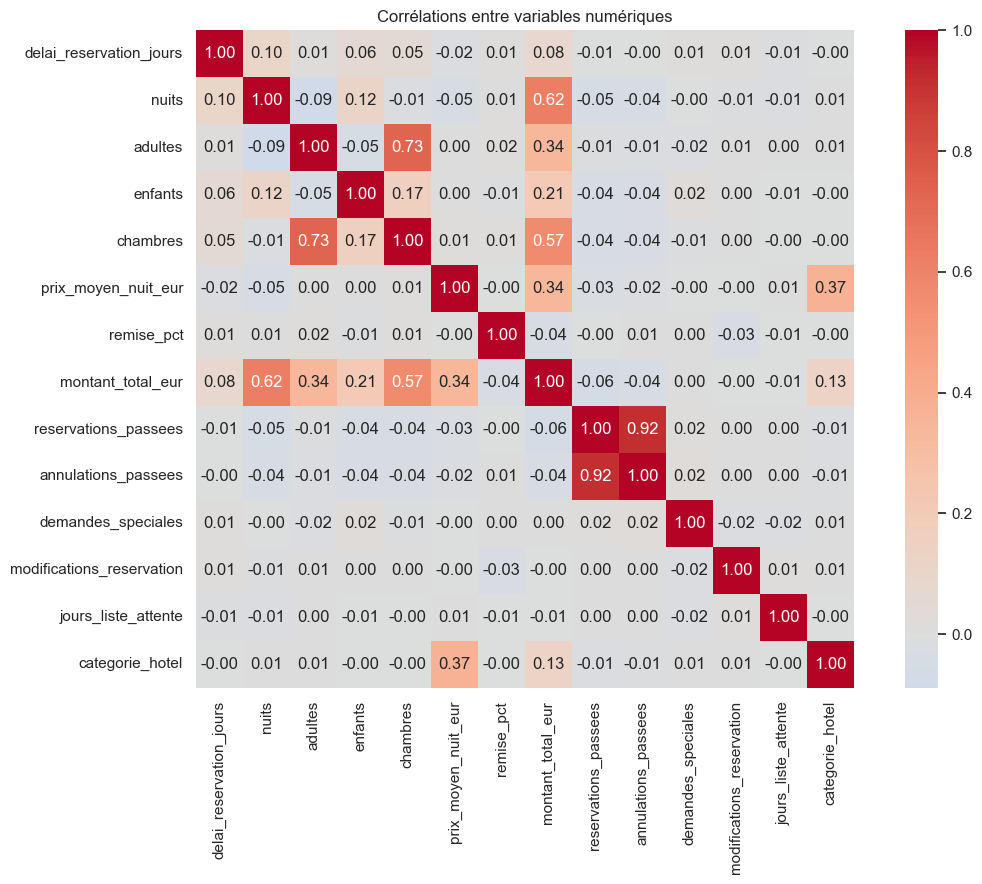

In [34]:
fig, ax = plt.subplots(figsize=(12,9))
corr_matrix = train[num_cols + ['categorie_hotel']].corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, square=True)
ax.set_title("Corrélations entre variables numériques")
plt.tight_layout()
plt.savefig('../report/figures/11_correlation_matrix.png', dpi=120)
plt.show()

**Constat :** prises isolément, les corrélations linéaires des variables numériques avec la cible sont
**faibles** (max ~0.11 pour `delai_reservation_jours`). Cela ne contredit pas les analyses par bucket
ci-dessus (relation non-linéaire/monotone plutôt que linéaire) — argument supplémentaire pour tester des
modèles non-linéaires (arbres) en plus de la régression logistique baseline, et pour construire des variables
dérivées (buckets, ratios, interactions) en feature engineering. Aucune paire de variables numériques ne
présente de colinéarité forte (>0.7) qui obligerait à en retirer une.